<font color='blue'> **02__ https://pages.nist.gov/fipy/en/latest/generated/examples.diffusion.mesh20x20.html  __** </font> <br>
<font color='blue'> **02__ https://stackoverflow.com/a/76601829  __** </font>  Gaussian surface

In [1]:
import numpy as np  ; import matplotlib.pyplot as plt                         ; import fipy as fp
from fipy import CellVariable, Grid2D, Viewer, TransientTerm, DiffusionTerm   ; from fipy.tools import numerix

In [2]:
%%capture
nx=20 ;ny=20   ;dx=1.;dy=1.  ;L=dx*nx     ;mesh = Grid2D(dx=dx, dy=dy, nx=nx, ny=ny)   ; phi=CellVariable(name="solution variable",mesh=mesh,value=0.)

D = 1.           ; eq = TransientTerm() == DiffusionTerm(coeff=D)                                    ; valueTopLeft=0;valueBottomRight=1                 ; X, Y = mesh.faceCenters
facesTopLeft     = ((mesh.facesLeft  & (Y>L/2)) | (mesh.facesTop    & (X<L/2)))                      ; phi.constrain(valueTopLeft     ,facesTopLeft)     # Neumann BC
facesBottomRight = ((mesh.facesRight & (Y<L/2)) | (mesh.facesBottom & (X>L/2)))                      ; phi.constrain(valueBottomRight ,facesBottomRight) ; print(len(phi.value))

In [3]:
timeStepDuration = 10 * 0.9 * dx**2 / (2 * D)       ; steps = 10
for step in range(steps):   eq.solve(var=phi,dt=timeStepDuration)

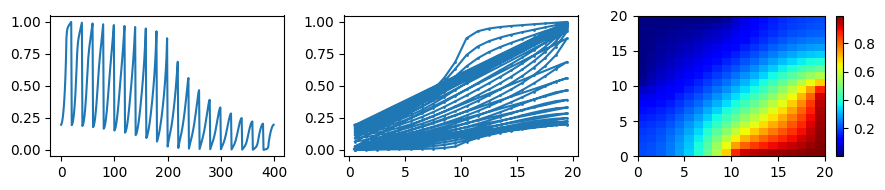

In [4]:
YY=phi.value  ;XX=np.linspace(0,len(YY)-1,num=len(YY))                                              ; XA = mesh.cellCenters[0] 
xx = mesh.cellCenters[0].value.reshape(nx, ny)   ; yy = mesh.cellCenters[1].value.reshape(nx, ny)   ; zz = phi.value  ; ZZ = zz.reshape(nx, ny)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(9, 2))                                          # ; print(valueBottomRight)
ax1.plot(XX,YY) ; ax2.plot(XA.value, phi.value, 'o-', markersize=1)         ;WW = ax3.pcolormesh(xx, yy, ZZ,cmap='jet') ;  cbar = plt.colorbar(WW)  ; plt.tight_layout() ; plt.show()

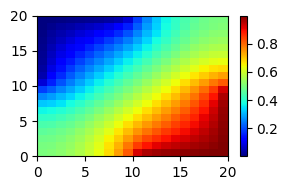

In [5]:
DiffusionTerm().solve(var=phi) ; phi2=phi
xx1 = mesh.cellCenters[0].value.reshape(nx, ny)   ; yy1 = mesh.cellCenters[1].value.reshape(nx, ny)   ; zz = phi2.value  ; ZZ1 = zz.reshape(nx, ny)
fig, (ax3) = plt.subplots(1, 1,figsize=(3, 2))   ; WW = ax3.pcolormesh(xx1, yy1, ZZ1,cmap='jet') ;  cbar = plt.colorbar(WW)  ; plt.tight_layout() ; plt.show()

In [6]:
print(xx1.shape), print(yy1.shape), print(ZZ1.shape)

(20, 20)
(20, 20)
(20, 20)


(None, None, None)